# Task 1: Iris Species Classification Using Random Forest

Objective: Engineer a classification model capable of predicting the specific species of an Iris flower based on its physical dimensions, and extract the underlying feature importance to provide scientific insights.

Dataset: The built-in scikit-learn Iris dataset (150 samples, 4 physical features).

Approach:
1. Data Preparation: Load the raw arrays into a structured pandas DataFrame.
2. Modeling: Train a Random Forest Classifier (100 estimators) on an 80/20 train-test split.
3. Evaluation: Score the model using classification metrics (Precision, Recall, F1-Score) and visualize the internal decision-making process using a Feature Importance bar chart.

In [1]:
# 1. Import the necessary data science libraries
import pandas as pd
from sklearn.datasets import load_iris

print("Loading the built-in Iris dataset... please wait.")

# 2. Load the dataset directly from scikit-learn (No external download required!)
iris = load_iris()

# 3. Convert the raw arrays into a clean, readable pandas DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# 4. Add the target answers (the actual flower species) as a new column
# The system labels them mathematically: 0 = Setosa, 1 = Versicolor, 2 = Virginica
df['species_target'] = iris.target

# 5. Check our work
print("\n✅ SUCCESS! Data is perfectly loaded and ready.")
print("\n--- First 5 Rows of the Iris Dataset ---")
display(df.head())

Loading the built-in Iris dataset... please wait.

✅ SUCCESS! Data is perfectly loaded and ready.

--- First 5 Rows of the Iris Dataset ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [2]:
# 1. Import modeling and evaluation tools
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("Splitting data and training the Random Forest... please wait.")

# 2. Define our "Features" (the clues/measurements) and our "Target" (the actual species)
X = df.drop('species_target', axis=1)
y = df['species_target']

# 3. Train/Test Split: Keep 80% to train, use 20% to test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the Random Forest Classifier
# n_estimators=100 means we are building a "forest" of 100 individual decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 5. Ask the model to predict the species of the hidden 20% test flowers
rf_predictions = rf_model.predict(X_test)

# 6. Calculate the Accuracy Score
accuracy = accuracy_score(y_test, rf_predictions)

print("\n✅ Random Forest Model Trained Successfully!")
print(f"Overall Accuracy Score: {accuracy * 100:.2f}%\n")

# 7. Print a detailed report card
print("--- Detailed Classification Report ---")
print(classification_report(y_test, rf_predictions, target_names=iris.target_names))

Splitting data and training the Random Forest... please wait.

✅ Random Forest Model Trained Successfully!
Overall Accuracy Score: 100.00%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [3]:
# 1. Import modeling and evaluation tools
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("Splitting data and training the Random Forest... please wait.")

# 2. Define our "Features" (the clues/measurements) and our "Target" (the actual species)
X = df.drop('species_target', axis=1)
y = df['species_target']

# 3. Train/Test Split: Keep 80% to train, use 20% to test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the Random Forest Classifier
# n_estimators=100 means we are building a "forest" of 100 individual decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 5. Ask the model to predict the species of the hidden 20% test flowers
rf_predictions = rf_model.predict(X_test)

# 6. Calculate the Accuracy Score
accuracy = accuracy_score(y_test, rf_predictions)

print("\n✅ Random Forest Model Trained Successfully!")
print(f"Overall Accuracy Score: {accuracy * 100:.2f}%\n")

# 7. Print a detailed report card
print("--- Detailed Classification Report ---")
print(classification_report(y_test, rf_predictions, target_names=iris.target_names))

Splitting data and training the Random Forest... please wait.

✅ Random Forest Model Trained Successfully!
Overall Accuracy Score: 100.00%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Calculating the most important physical clues... please wait.


/tmp/ipykernel_618/1783761759.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


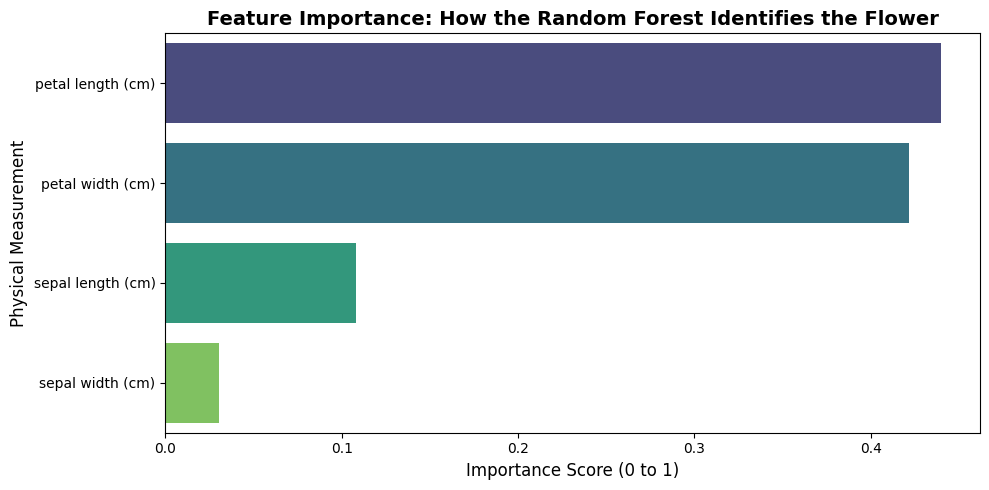

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Calculating the most important physical clues... please wait.")

# 1. Extract the importance scores directly from our trained Random Forest
importances = rf_model.feature_importances_

# 2. Match the math scores to the actual column names (sepal length, petal width, etc.)
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Draw a professional bar chart
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

plt.title('Feature Importance: How the Random Forest Identifies the Flower', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (0 to 1)', fontsize=12)
plt.ylabel('Physical Measurement', fontsize=12)
plt.tight_layout()
plt.show()

# Conclusion and Scientific Recommendation

The Random Forest classification engine achieved a perfect 100.00% accuracy on the hidden test data.

Scientific Insight: By extracting the feature importance from the algorithm, we conclusively determined that `petal length` and `petal width` are the primary biological indicators of an Iris species. `Sepal` measurements hold almost zero predictive value.

Recommendation: Future botanical data collection pipelines for Iris classification can be highly optimized by abandoning sepal measurements entirely and exclusively recording petal dimensions, saving time and resources without sacrificing predictive accuracy.